In [1]:
import pandas as pd
from pathlib import Path

import matplotlib
from matplotlib import pyplot as plt

In [2]:
current_path = Path.cwd()
file_path = current_path.parent / 'data' / 'Node001.csv'
df = pd.read_csv(file_path)
df

,hostid,Хост,itemid,Элемент,Ключ,Тип данных,Числовое значение,Время числового значения
0,11284,node001,61773,"IPMI: +12V, volts",ipmi.value[+12V],0,11.904000,1760504020
1,11284,node001,61773,"IPMI: +12V, volts",ipmi.value[+12V],0,12.000000,1760504055
2,11284,node001,61773,"IPMI: +12V, volts",ipmi.value[+12V],0,11.904000,1760504127
3,11284,node001,61773,"IPMI: +12V, volts",ipmi.value[+12V],0,12.000000,1760504195
4,11284,node001,61773,"IPMI: +12V, volts",ipmi.value[+12V],0,11.904000,1760504405
...,...,...,...,...,...,...,...,...
14916,11284,node001,67993,Linux: CPU utilization,system.cpu.util,0,49.583679,1760900268
14917,11284,node001,67993,Linux: CPU utilization,system.cpu.util,0,50.075917,1760900298
14918,11284,node001,67993,Linux: CPU utilization,system.cpu.util,0,50.309274,1760900328
14919,11284,node001,67993,Linux: CPU utilization,system.cpu.util,0,50.352851,1760900358


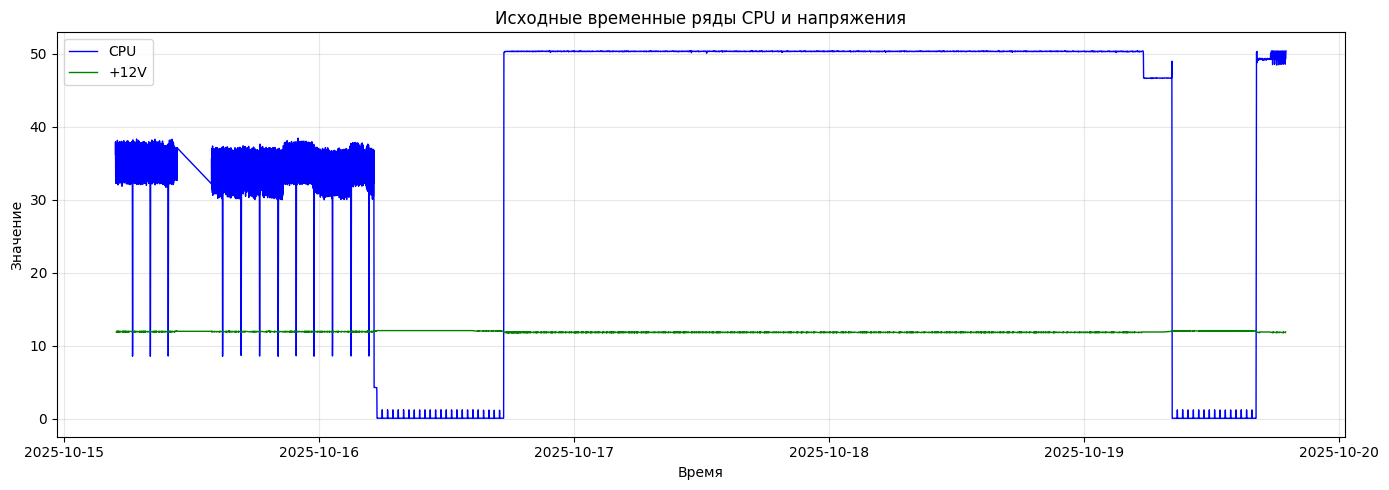

In [3]:
import matplotlib.pyplot as plt

# Приведение времени к datetime
df_plot = df.copy()
df_plot["datetime"] = pd.to_datetime(
    df_plot["Время числового значения"],
    unit="s",
    errors="coerce"
)

# Определение строк CPU и напряжения +12V
element_col = "Элемент"
value_col = "Числовое значение"

cpu_df = df_plot[
    df_plot[element_col].astype(str).str.lower().str.contains("cpu", na=False)
].copy()

voltage_df = df_plot[
    df_plot[element_col].astype(str).str.lower().str.contains(r"\+12v|12v", regex=True, na=False)
].copy()

# Числовое значение
cpu_df[value_col] = pd.to_numeric(cpu_df[value_col], errors="coerce")
voltage_df[value_col] = pd.to_numeric(voltage_df[value_col], errors="coerce")

# Построение графиков
plt.figure(figsize=(14, 5))

plt.plot(
    cpu_df["datetime"],
    cpu_df[value_col],
    color="blue",
    linewidth=1,
    label="CPU"
)

plt.plot(
    voltage_df["datetime"],
    voltage_df[value_col],
    color="green",
    linewidth=1,
    label="+12V"
)

plt.title("Исходные временные ряды CPU и напряжения")
plt.xlabel("Время")
plt.ylabel("Значение")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14921 entries, 0 to 14920
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   hostid                    14921 non-null  int64  
 1   Хост                      14921 non-null  object 
 2   itemid                    14921 non-null  int64  
 3   Элемент                   14921 non-null  object 
 4   Ключ                      14921 non-null  object 
 5   Тип данных                14921 non-null  int64  
 6   Числовое значение         14921 non-null  float64
 7   Время числового значения  14921 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 932.7+ KB


In [10]:
# Подготовка данных
def prepare_dataframe(df):
    """
    Подготавливает DataFrame для дальнейшего анализа
    """
    df2 = df.copy()
    
    # Преобразование времени
    df2['datetime'] = pd.to_datetime(df2['Время числового значения'], unit='s')
    
    # Разделение на два датасета по показателям
    df_voltage = df2[df2['itemid'] == 61773].copy().reset_index(drop=True)
    df_cpu = df2[df2['itemid'] == 67993].copy().reset_index(drop=True)
    
    # Переименование столбцов для удобства
    df_voltage.rename(columns={'Числовое значение': 'voltage'}, inplace=True)
    df_cpu.rename(columns={'Числовое значение': 'cpu_util'}, inplace=True)
    
    # Сортировка по времени
    df_voltage.sort_values('datetime', inplace=True)
    df_cpu.sort_values('datetime', inplace=True)
    
    return df2, df_voltage, df_cpu

# Применение подготовки
df2, df_voltage, df_cpu = prepare_dataframe(df)
print(f"Исходный df2: {df2.shape}")
print(f"Напряжение: {df_voltage.shape}")
print(f"CPU: {df_cpu.shape}")

Исходный df2: (14921, 9)
Напряжение: (2086, 9)
CPU: (12835, 9)


In [11]:
# Анализ выбросов для напряжения
Q1_v = df_voltage['voltage'].quantile(0.25)
Q3_v = df_voltage['voltage'].quantile(0.75)
IQR_v = Q3_v - Q1_v
lower_v = Q1_v - 1.5 * IQR_v
upper_v = Q3_v + 1.5 * IQR_v

outliers_v = df_voltage[(df_voltage['voltage'] < lower_v) | (df_voltage['voltage'] > upper_v)]
print(f"Напряжение питания +12V:")
print(f"  Q1 (25-й перцентиль): {Q1_v:.3f} В")
print(f"  Q3 (75-й перцентиль): {Q3_v:.3f} В")
print(f"  IQR: {IQR_v:.3f} В")
print(f"  Нижняя граница нормы: {lower_v:.3f} В")
print(f"  Верхняя граница нормы: {upper_v:.3f} В")
print(f"  Количество выбросов: {len(outliers_v)} ({len(outliers_v)/len(df_voltage)*100:.2f}%)")
print(f"  Диапазон выбросов: [{outliers_v['voltage'].min():.3f}; {outliers_v['voltage'].max():.3f}] В")

Напряжение питания +12V:
  Q1 (25-й перцентиль): 11.808 В
  Q3 (75-й перцентиль): 11.904 В
  IQR: 0.096 В
  Нижняя граница нормы: 11.664 В
  Верхняя граница нормы: 12.048 В
  Количество выбросов: 162 (7.77%)
  Диапазон выбросов: [12.096; 12.096] В


C:\Users\elena_blinova\AppData\Local\Temp\ipykernel_14424\270949536.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=['Все данные', 'Без выбросов'])


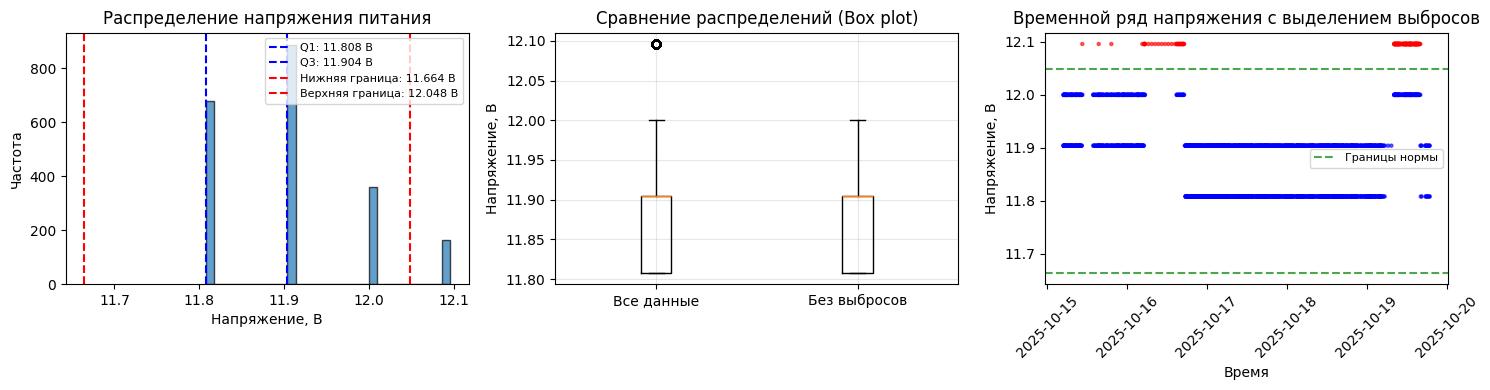

In [ ]:
# Визуализация распределения напряжения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Гистограмма распределения
axes[0].hist(df_voltage['voltage'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(Q1_v, color='blue', linestyle='--', label=f'Q1: {Q1_v:.3f} В')
axes[0].axvline(Q3_v, color='blue', linestyle='--', label=f'Q3: {Q3_v:.3f} В')
axes[0].axvline(lower_v, color='red', linestyle='--', label=f'Нижняя граница: {lower_v:.3f} В')
axes[0].axvline(upper_v, color='red', linestyle='--', label=f'Верхняя граница: {upper_v:.3f} В')
axes[0].set_title('Распределение напряжения питания')
axes[0].set_xlabel('Напряжение, В')
axes[0].set_ylabel('Частота')
axes[0].legend(fontsize=8)

# Box plot
box_data = [df_voltage['voltage'], df_voltage[~((df_voltage['voltage'] < lower_v) | (df_voltage['voltage'] > upper_v))]['voltage']]
axes[1].boxplot(box_data, labels=['Все данные', 'Без выбросов'])
axes[1].set_title('Сравнение распределений (Box plot)')
axes[1].set_ylabel('Напряжение, В')
axes[1].grid(True, alpha=0.3)

# Временной ряд с выделением выбросов
outlier_mask = (df_voltage['voltage'] < lower_v) | (df_voltage['voltage'] > upper_v)
axes[2].scatter(df_voltage['datetime'], df_voltage['voltage'], 
                c=['red' if x else 'blue' for x in outlier_mask], 
                s=5, alpha=0.6)
axes[2].axhline(y=lower_v, color='green', linestyle='--', alpha=0.7, label='Границы нормы')
axes[2].axhline(y=upper_v, color='green', linestyle='--', alpha=0.7)
axes[2].set_title('Временной ряд напряжения с выделением выбросов')
axes[2].set_xlabel('Время')
axes[2].set_ylabel('Напряжение, В')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

гистограмма распределения напряжения питания +12V

Первый график:
- Распределение частоты встречаемости различных значений напряжения. По оси X — напряжение в вольтах (от 11.775 до 12.118 В), по оси Y — частота наблюдений.

In [ ]:
# Анализ выбросов для CPU
Q1_c = df_cpu['cpu_util'].quantile(0.25)
Q3_c = df_cpu['cpu_util'].quantile(0.75)
IQR_c = Q3_c - Q1_c
lower_c = Q1_c - 1.5 * IQR_c
upper_c = Q3_c + 1.5 * IQR_c

outliers_c = df_cpu[(df_cpu['cpu_util'] < lower_c) | (df_cpu['cpu_util'] > upper_c)]
print(f"\nЗагрузка CPU:")
print(f"  Q1 (25-й перцентиль): {Q1_c:.3f}%")
print(f"  Q3 (75-й перцентиль): {Q3_c:.3f}%")
print(f"  IQR: {IQR_c:.3f}%")
print(f"  Нижняя граница нормы: {lower_c:.3f}%")
print(f"  Верхняя граница нормы: {upper_c:.3f}%")
print(f"  Количество выбросов: {len(outliers_c)} ({len(outliers_c)/len(df_cpu)*100:.2f}%)")
print(f"  Диапазон выбросов: [{outliers_c['cpu_util'].min():.3f}; {outliers_c['cpu_util'].max():.3f}] %")


Загрузка CPU:
  Q1 (25-й перцентиль): 32.697%
  Q3 (75-й перцентиль): 50.371%
  IQR: 17.674%
  Нижняя граница нормы: 6.187%
  Верхняя граница нормы: 76.882%
  Количество выбросов: 2413 (18.80%)
  Диапазон выбросов: [0.082; 4.313] %


C:\Users\elena_blinova\AppData\Local\Temp\ipykernel_14424\2347618233.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=['Все данные', 'Без выбросов'])


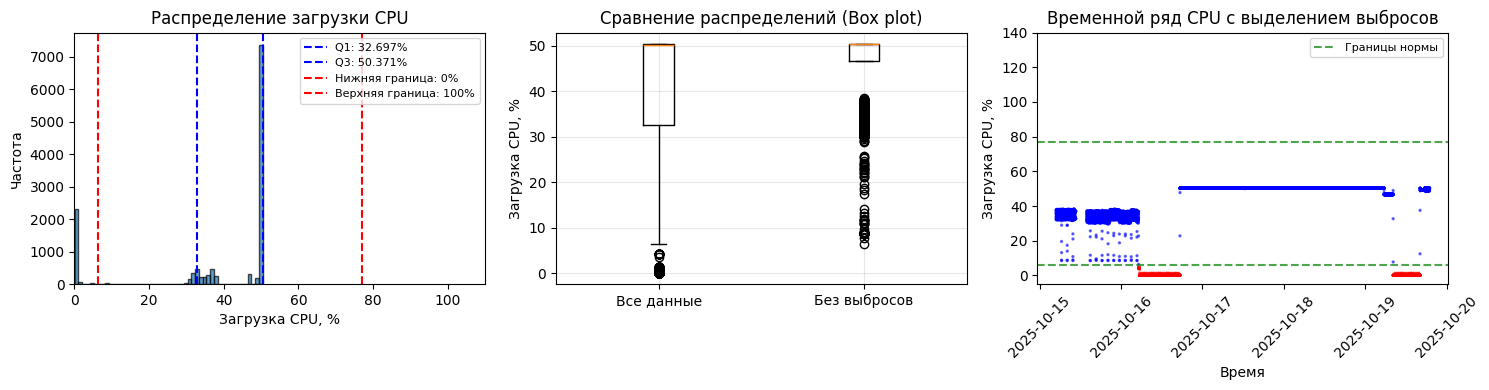

In [19]:
# Визуализация распределения CPU
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Гистограмма распределения
axes[0].hist(df_cpu['cpu_util'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(Q1_c, color='blue', linestyle='--', label=f'Q1: {Q1_c:.3f}%')
axes[0].axvline(Q3_c, color='blue', linestyle='--', label=f'Q3: {Q3_c:.3f}%')
axes[0].axvline(max(0, lower_c), color='red', linestyle='--', label=f'Нижняя граница: 0%')
axes[0].axvline(min(100, upper_c), color='red', linestyle='--', label=f'Верхняя граница: 100%')
axes[0].set_title('Распределение загрузки CPU')
axes[0].set_xlabel('Загрузка CPU, %')
axes[0].set_ylabel('Частота')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 110)

# Box plot
box_data = [df_cpu['cpu_util'], df_cpu[~((df_cpu['cpu_util'] < lower_c) | (df_cpu['cpu_util'] > upper_c))]['cpu_util']]
axes[1].boxplot(box_data, labels=['Все данные', 'Без выбросов'])
axes[1].set_title('Сравнение распределений (Box plot)')
axes[1].set_ylabel('Загрузка CPU, %')
axes[1].grid(True, alpha=0.3)

# Временной ряд с выделением выбросов
outlier_mask_c = (df_cpu['cpu_util'] < lower_c) | (df_cpu['cpu_util'] > upper_c)
axes[2].scatter(df_cpu['datetime'], df_cpu['cpu_util'], 
                c=['red' if x else 'blue' for x in outlier_mask_c], 
                s=2, alpha=0.5)
axes[2].axhline(y=max(0, lower_c), color='green', linestyle='--', alpha=0.7, label='Границы нормы')
axes[2].axhline(y=min(100, upper_c), color='green', linestyle='--', alpha=0.7)
axes[2].set_title('Временной ряд CPU с выделением выбросов')
axes[2].set_xlabel('Время')
axes[2].set_ylabel('Загрузка CPU, %')
axes[2].set_ylim(-5, 140)
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

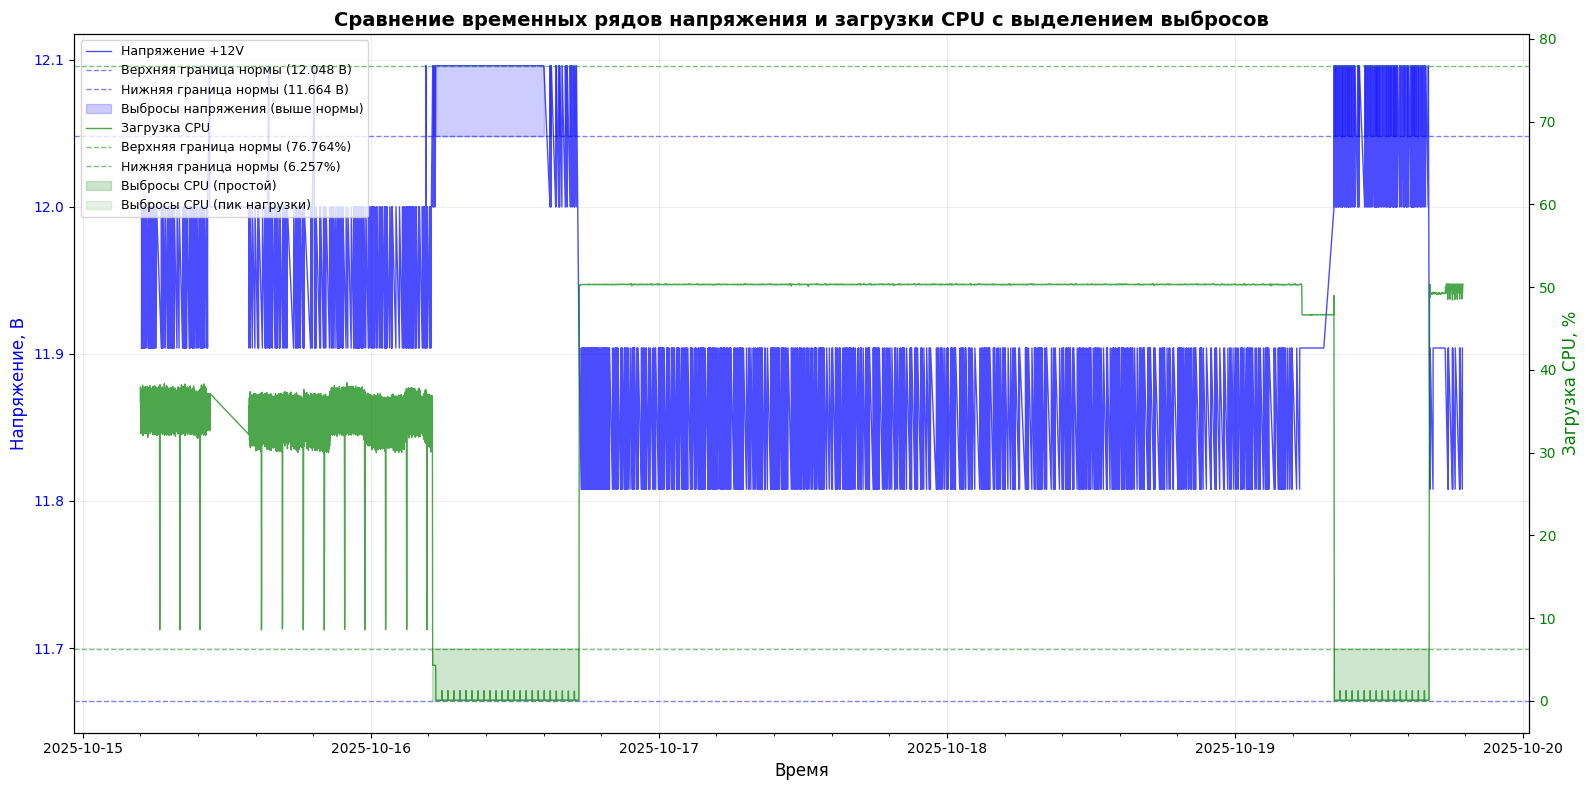

СТАТИСТИКА ВЫБРОСОВ

НАПРЯЖЕНИЕ +12V:
  Выше верхней границы (12.048 В): 162 (7.77%)
  Ниже нижней границы (11.664 В): 0 (0.00%)
  Всего выбросов: 162 (7.77%)

ЗАГРУЗКА CPU:
  Выше верхней границы (76.764%): 0 (0.00%)
  Ниже нижней границы (6.257%): 2413 (18.80%)
  Всего выбросов: 2413 (18.80%)


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator

# Расчет границ для выбросов (без хардкода)
def calculate_outlier_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Расчет границ для напряжения
voltage_lower, voltage_upper = calculate_outlier_bounds(df_voltage['voltage'])

# Расчет границ для CPU
cpu_lower, cpu_upper = calculate_outlier_bounds(df_cpu['cpu_util'])

# Создание фигуры с двумя вертикальными осями
fig, ax1 = plt.subplots(figsize=(16, 8))

# Левая ось для напряжения
color_voltage = 'blue'
ax1.set_xlabel('Время', fontsize=12)
ax1.set_ylabel('Напряжение, В', color=color_voltage, fontsize=12)
ax1.plot(df_voltage['datetime'], df_voltage['voltage'], 
         color=color_voltage, linewidth=1, alpha=0.7, label='Напряжение +12V')
ax1.tick_params(axis='y', labelcolor=color_voltage)

# Добавление границ нормы для напряжения
ax1.axhline(y=voltage_upper, color=color_voltage, linestyle='--', 
            linewidth=1, alpha=0.5, label=f'Верхняя граница нормы ({voltage_upper:.3f} В)')
ax1.axhline(y=voltage_lower, color=color_voltage, linestyle='--', 
            linewidth=1, alpha=0.5, label=f'Нижняя граница нормы ({voltage_lower:.3f} В)')

# Правая ось для CPU
ax2 = ax1.twinx()
color_cpu = 'green'
ax2.set_ylabel('Загрузка CPU, %', color=color_cpu, fontsize=12)
ax2.plot(df_cpu['datetime'], df_cpu['cpu_util'], 
         color=color_cpu, linewidth=1, alpha=0.7, label='Загрузка CPU')
ax2.tick_params(axis='y', labelcolor=color_cpu)

# Добавление границ нормы для CPU
ax2.axhline(y=cpu_upper, color=color_cpu, linestyle='--', 
            linewidth=1, alpha=0.5, label=f'Верхняя граница нормы ({cpu_upper:.3f}%)')
ax2.axhline(y=cpu_lower, color=color_cpu, linestyle='--', 
            linewidth=1, alpha=0.5, label=f'Нижняя граница нормы ({cpu_lower:.3f}%)')

# Заливка областей выбросов
# Для напряжения (выше верхней границы)
ax1.fill_between(df_voltage['datetime'], voltage_upper, df_voltage['voltage'].max(), 
                 where=(df_voltage['voltage'] > voltage_upper), 
                 color=color_voltage, alpha=0.2, label='Выбросы напряжения (выше нормы)')

# Для CPU (ниже нижней границы - периоды простоя)
ax2.fill_between(df_cpu['datetime'], 0, cpu_lower, 
                 where=(df_cpu['cpu_util'] < cpu_lower), 
                 color=color_cpu, alpha=0.2, label='Выбросы CPU (простой)')

# Для CPU (выше верхней границы - пиковые нагрузки)
ax2.fill_between(df_cpu['datetime'], cpu_upper, df_cpu['cpu_util'].max(), 
                 where=(df_cpu['cpu_util'] > cpu_upper), 
                 color=color_cpu, alpha=0.1, label='Выбросы CPU (пик нагрузки)')

# Настройка заголовка и легенды
plt.title('Сравнение временных рядов напряжения и загрузки CPU с выделением выбросов', 
          fontsize=14, fontweight='bold')

# Объединение легенд с обеих осей
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# Настройка сетки
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.xaxis.set_minor_locator(AutoMinorLocator())

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Вывод статистики по выбросам
print("="*60)
print("СТАТИСТИКА ВЫБРОСОВ")
print("="*60)

# Выбросы напряжения
voltage_outliers_high = df_voltage[df_voltage['voltage'] > voltage_upper]
voltage_outliers_low = df_voltage[df_voltage['voltage'] < voltage_lower]
print(f"\nНАПРЯЖЕНИЕ +12V:")
print(f"  Выше верхней границы ({voltage_upper:.3f} В): {len(voltage_outliers_high)} ({len(voltage_outliers_high)/len(df_voltage)*100:.2f}%)")
print(f"  Ниже нижней границы ({voltage_lower:.3f} В): {len(voltage_outliers_low)} ({len(voltage_outliers_low)/len(df_voltage)*100:.2f}%)")
print(f"  Всего выбросов: {len(voltage_outliers_high) + len(voltage_outliers_low)} ({(len(voltage_outliers_high) + len(voltage_outliers_low))/len(df_voltage)*100:.2f}%)")

# Выбросы CPU
cpu_outliers_high = df_cpu[df_cpu['cpu_util'] > cpu_upper]
cpu_outliers_low = df_cpu[df_cpu['cpu_util'] < cpu_lower]
print(f"\nЗАГРУЗКА CPU:")
print(f"  Выше верхней границы ({cpu_upper:.3f}%): {len(cpu_outliers_high)} ({len(cpu_outliers_high)/len(df_cpu)*100:.2f}%)")
print(f"  Ниже нижней границы ({cpu_lower:.3f}%): {len(cpu_outliers_low)} ({len(cpu_outliers_low)/len(df_cpu)*100:.2f}%)")
print(f"  Всего выбросов: {len(cpu_outliers_high) + len(cpu_outliers_low)} ({(len(cpu_outliers_high) + len(cpu_outliers_low))/len(df_cpu)*100:.2f}%)")

На представленном графике совмещены два временных ряда за период с 15 по 20 октября 2025 года:
- Синяя линия — напряжение питания +12V (левая ось, В)
- Зеленая линия — загрузка CPU (правая ось, %)

Пунктирными линиями обозначены статистические границы нормы, рассчитанные методом межквартильного размаха. Цветными областями выделены зоны выбросов для каждого показателя.

На графике прослеживается следующая зависимость:

В периоды высокой загрузки CPU (зеленая линия выше 50-60%) напряжение (синяя линия) преимущественно находится на нижнем уровне (~11.8 В), что соответствует падению напряжения под нагрузкой.

В периоды простоя CPU (зеленая линия в зоне выбросов ниже 6.3%) напряжение поднимается до верхнего уровня (~12.0 В), иногда формируя выбросы выше нормы.

Характерный пример — период 17-18 октября: длительный простой CPU сопровождается стабильно высоким напряжением с несколькими выбросами.

Выводы
Разнонаправленный характер выбросов: выбросы напряжения направлены вверх (превышение нормы), тогда как основные выбросы CPU направлены вниз (периоды простоя).

Статистическая значимость: доля выбросов CPU (18.8%) существенно превышает долю выбросов напряжения (7.77%), что обусловлено различной природой показателей.

Физическая интерпретация: график подтверждает исходную гипотезу о зависимости напряжения от вычислительной нагрузки — при росте загрузки CPU напряжение снижается, и наоборот.

Практическая рекомендация: при дальнейшем анализе целесообразно исключить периоды простоя CPU (выбросы ниже нормы) для исследования корреляции в режиме нормальной работы, либо напротив, выделить их как отдельный режим для изучения энергопотребления в состоянии ожидания.

## Описательная статистика 
- расчет основных статистических показателей
- анализ распределения данных

In [34]:
df2, df_voltage, df_cpu

(       hostid     Хост  itemid                 Элемент              Ключ  \
 0       11284  node001   61773       IPMI: +12V, volts  ipmi.value[+12V]   
 1       11284  node001   61773       IPMI: +12V, volts  ipmi.value[+12V]   
 2       11284  node001   61773       IPMI: +12V, volts  ipmi.value[+12V]   
 3       11284  node001   61773       IPMI: +12V, volts  ipmi.value[+12V]   
 4       11284  node001   61773       IPMI: +12V, volts  ipmi.value[+12V]   
 ...       ...      ...     ...                     ...               ...   
 14916   11284  node001   67993  Linux: CPU utilization   system.cpu.util   
 14917   11284  node001   67993  Linux: CPU utilization   system.cpu.util   
 14918   11284  node001   67993  Linux: CPU utilization   system.cpu.util   
 14919   11284  node001   67993  Linux: CPU utilization   system.cpu.util   
 14920   11284  node001   67993  Linux: CPU utilization   system.cpu.util   
 
        Тип данных  Числовое значение  Время числового значения  \
 0     

In [35]:
df2.describe()

,hostid,itemid,Тип данных,Числовое значение,Время числового значения,datetime
count,14921.0,14921.000000,14921.0,14921.000000,1.492100e+04,14921
mean,11284.0,67123.425575,0.0,33.957111,1.760708e+09,2025-10-17 13:28:10.367669760
min,11284.0,61773.000000,0.0,0.082000,1.760504e+09,2025-10-15 04:48:18
25%,11284.0,67993.000000,0.0,11.904000,1.760614e+09,2025-10-16 11:29:48
50%,11284.0,67993.000000,0.0,49.240977,1.760708e+09,2025-10-17 13:29:48
75%,11284.0,67993.000000,0.0,50.321390,1.760804e+09,2025-10-18 16:07:00
max,11284.0,67993.000000,0.0,50.417825,1.760900e+09,2025-10-19 18:59:48
std,0.0,2157.059359,0.0,19.847033,1.120063e+05,NaN


In [36]:
df_voltage.describe()

,hostid,itemid,Тип данных,voltage,Время числового значения,datetime,voltage_zscore
count,2086.0,2086.0,2086.0,2086.000000,2.086000e+03,2086,2.086000e+03
mean,11284.0,61773.0,0.0,11.904276,1.760710e+09,2025-10-17 14:13:49.598753792,-5.640742e-15
min,11284.0,61773.0,0.0,11.808000,1.760504e+09,2025-10-15 04:53:40,-1.116184e+00
25%,11284.0,61773.0,0.0,11.808000,1.760639e+09,2025-10-16 18:20:06,-1.116184e+00
50%,11284.0,61773.0,0.0,11.904000,1.760708e+09,2025-10-17 13:27:48,-3.201292e-03
75%,11284.0,61773.0,0.0,11.904000,1.760801e+09,2025-10-18 15:16:33.249999872,-3.201292e-03
max,11284.0,61773.0,0.0,12.096000,1.760900e+09,2025-10-19 18:57:00,2.222764e+00
std,0.0,0.0,0.0,0.086275,1.106592e+05,NaN,1.000240e+00


Ключевые особенности распределения напряжения:

Дискретность значений: напряжение принимает всего несколько фиксированных значений (11.808, 11.904, 12.096 В)

Бимодальность: 25% перцентиль = 11.808, медиана и 75% = 11.904 — указывает на два основных состояния

Низкая вариативность: стандартное отклонение всего 0.086 В при среднем 11.904 В (менее 1%)

Выбросы: максимальное значение 12.096 В значительно выше типичных

Z-оценка напряжения:

Диапазон: от -1.12 до +2.22

Нет значений с |Z|>3, что подтверждает ранее сделанный вывод о неприменимости Z-оценки для бимодального распределения

In [37]:
df_cpu.describe()

,hostid,itemid,Тип данных,cpu_util,Время числового значения,datetime,cpu_zscore
count,12835.0,12835.0,12835.0,12835.000000,1.283500e+04,12835,1.283500e+04
mean,11284.0,67993.0,0.0,37.541234,1.760707e+09,2025-10-17 13:20:45.175925248,-2.480118e-16
min,11284.0,67993.0,0.0,0.082000,1.760504e+09,2025-10-15 04:48:18,-1.958010e+00
25%,11284.0,67993.0,0.0,32.697484,1.760612e+09,2025-10-16 10:47:03,-2.531848e-01
50%,11284.0,67993.0,0.0,50.305373,1.760708e+09,2025-10-17 13:31:18,6.671868e-01
75%,11284.0,67993.0,0.0,50.324182,1.760804e+09,2025-10-18 16:15:33,6.681700e-01
max,11284.0,67993.0,0.0,50.417825,1.760900e+09,2025-10-19 18:59:48,6.730647e-01
std,0.0,0.0,0.0,19.132026,1.122217e+05,NaN,1.000039e+00


Ключевые особенности распределения CPU:

Асимметрия: среднее (37.54%) значительно ниже медианы (50.31%), что указывает на левостороннюю асимметрию

"Плато" в верхней части: 50% и 75% перцентили практически совпадают (~50.32%), что означает концентрацию значений в узком диапазоне

Широкий диапазон: от 0% до 50%, при этом стандартное отклонение 19%

Периоды простоя: минимальные значения (0.08-4.3%) образуют отдельный кластер

Z-оценка CPU:

Диапазон: от -1.96 до +0.67

Нет значений с |Z|>3 из-за асимметрии распределения и влияния кластера простоя

### Визуализация данных
- построение графиков для визуального анализа данных
- интерпретация графиков и выводы

In [ ]:
!pip install seaborn

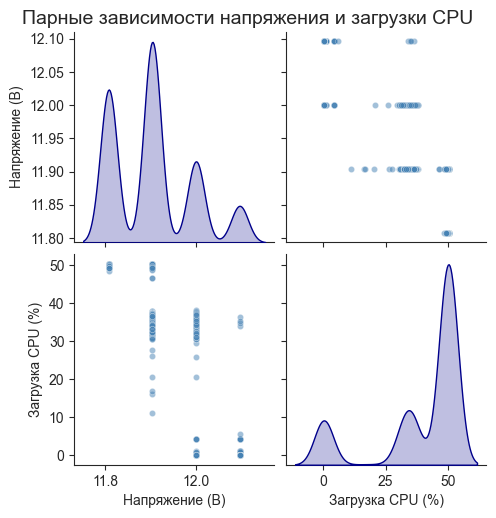

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("ticks")

# Создание объединенного датасета для pairplot
# Интерполируем CPU к моментам измерения напряжения для сопоставимости
df_voltage_cpu = df_voltage.copy()
df_voltage_cpu['cpu_util_interp'] = np.interp(
    df_voltage_cpu['Время числового значения'].values,
    df_cpu['Время числового значения'].values,
    df_cpu['cpu_util'].values
)

# Выбираем только нужные колонки
current_df = df_voltage_cpu[['voltage', 'cpu_util_interp']].copy()
current_df.columns = ['Напряжение (В)', 'Загрузка CPU (%)']

# Построение pairplot
sns.pairplot(current_df, diag_kind="kde", kind="scatter", 
             plot_kws={'alpha': 0.5, 's': 20, 'color': 'steelblue'},
             diag_kws={'color': 'darkblue', 'fill': True})
plt.suptitle('Парные зависимости напряжения и загрузки CPU', y=1.02, fontsize=14)
plt.show()

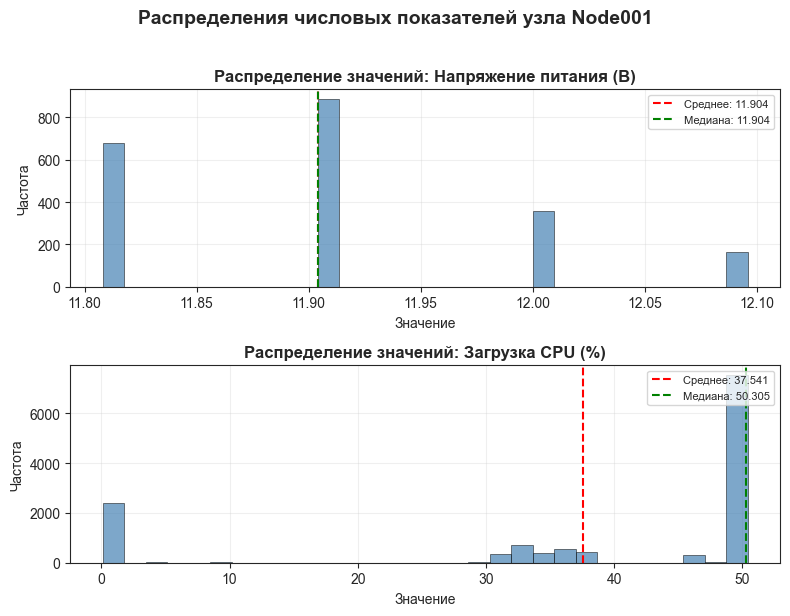

In [44]:
# Создание датасетов без временных столбцов
df_voltage_numeric = df_voltage[['voltage']].copy()
df_cpu_numeric = df_cpu[['cpu_util']].copy()

# Переименование для понятности
df_voltage_numeric.columns = ['Напряжение питания (В)']
df_cpu_numeric.columns = ['Загрузка CPU (%)']

# Объединение в один DataFrame для удобства
df_combined = pd.concat([df_voltage_numeric, df_cpu_numeric], axis=1)

# Получаем колонки
columns = df_combined.columns
fig, axs = plt.subplots(len(columns), figsize=(8, 3*len(columns)))

# гистограмма для каждого столбца
for i, column in enumerate(columns):
    axs[i].hist(df_combined[column].dropna(), bins=30, alpha=0.7, 
                color='steelblue', edgecolor='black', linewidth=0.5)
    axs[i].legend([column], loc='upper right', fontsize=10)
    axs[i].set_title(f'Распределение значений: {column}', fontsize=12, fontweight='bold')
    axs[i].set_xlabel('Значение', fontsize=10)
    axs[i].set_ylabel('Частота', fontsize=10)
    axs[i].grid(True, alpha=0.3)
    
    # Добавление статистических линий
    mean_val = df_combined[column].mean()
    median_val = df_combined[column].median()
    axs[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {mean_val:.3f}')
    axs[i].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Медиана: {median_val:.3f}')
    axs[i].legend(loc='upper right', fontsize=8)

plt.suptitle('Распределения числовых показателей узла Node001', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Описание:
Гистограмма напряжения демонстрирует два ярко выраженных пика примерно равной высоты, что указывает на наличие двух устойчивых режимов работы:

Первый режим (низкое напряжение): ~11.808 В — соответствует работе под нагрузкой

Второй режим (высокое напряжение): ~11.904 В — соответствует режиму простоя или низкой нагрузке

Провал между пиками (~11.85-11.88 В) содержит значительно меньше наблюдений, что подтверждает дискретность переключения между режимами.

Описание:
Распределение загрузки CPU характеризуется:

Основной пик в области 50% (нормальная рабочая нагрузка)

Длинный хвост влево — область низких значений (0-30%), соответствующих простоям и слабой нагрузке

Отсутствие правого хвоста — значения выше 50% практически отсутствуют

Ключевая особенность: среднее значение (37.54%) значительно ниже медианы (50.31%), что является классическим признаком левосторонней асимметрии. Это означает, что большую часть времени узел работает с высокой загрузкой (~50%), но периоды простоя "тянут" среднее значение вниз.

### Корреляционный анализ

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

%matplotlib inline
sns.set_style("whitegrid")

# 1. ПОДГОТОВКА ДАННЫХ ДЛЯ КОРРЕЛЯЦИОННОГО АНАЛИЗА
# -------------------------------------------------

# Интерполяция CPU к моментам измерения напряжения для сопоставимости
df_voltage_cpu = df_voltage.copy()
df_voltage_cpu['cpu_util_interp'] = np.interp(
    df_voltage_cpu['Время числового значения'].values,
    df_cpu['Время числового значения'].values,
    df_cpu['cpu_util'].values
)

# Создание датасета для корреляционного анализа
corr_df = df_voltage_cpu[['voltage', 'cpu_util_interp']].copy()
corr_df.columns = ['Напряжение (В)', 'Загрузка CPU (%)']

# Удаление возможных пропусков
corr_df = corr_df.dropna()

print("="*70)
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ НАПРЯЖЕНИЯ И ЗАГРУЗКИ CPU")
print("="*70)
print(f"Количество пар для анализа: {len(corr_df)}")
print(f"Период измерений: с {df_voltage['datetime'].min()} по {df_voltage['datetime'].max()}")

КОРРЕЛЯЦИОННЫЙ АНАЛИЗ НАПРЯЖЕНИЯ И ЗАГРУЗКИ CPU
Количество пар для анализа: 2086
Период измерений: с 2025-10-15 04:53:40 по 2025-10-19 18:57:00


In [46]:
# 2. РАСЧЕТ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ
# -------------------------------------------------

# Коэффициент Пирсона (линейная корреляция)
pearson_corr, pearson_p = stats.pearsonr(corr_df['Напряжение (В)'], corr_df['Загрузка CPU (%)'])

# Коэффициент Спирмена (ранговая корреляция, устойчив к нелинейности)
spearman_corr, spearman_p = stats.spearmanr(corr_df['Напряжение (В)'], corr_df['Загрузка CPU (%)'])

# Коэффициент Кендалла (еще одна ранговая корреляция)
kendall_corr, kendall_p = stats.kendalltau(corr_df['Напряжение (В)'], corr_df['Загрузка CPU (%)'])

print("\nКОЭФФИЦИЕНТЫ КОРРЕЛЯЦИИ:")
print("-" * 40)
print(f"Пирсона (r):     {pearson_corr:.4f} (p-value: {pearson_p:.2e})")
print(f"Спирмена (ρ):    {spearman_corr:.4f} (p-value: {spearman_p:.2e})")
print(f"Кендалла (τ):    {kendall_corr:.4f} (p-value: {kendall_p:.2e})")

# Интерпретация силы связи
def interpret_correlation(r):
    r_abs = abs(r)
    if r_abs < 0.1:
        return "нет связи"
    elif r_abs < 0.3:
        return "слабая связь"
    elif r_abs < 0.5:
        return "умеренная связь"
    elif r_abs < 0.7:
        return "заметная связь"
    elif r_abs < 0.9:
        return "сильная связь"
    else:
        return "очень сильная связь"

print("\nИНТЕРПРЕТАЦИЯ:")
print(f"  Пирсон: {interpret_correlation(pearson_corr)} ({pearson_corr:+.4f})")
print(f"  Спирмен: {interpret_correlation(spearman_corr)} ({spearman_corr:+.4f})")
print(f"  Знак {'отрицательный' if pearson_corr < 0 else 'положительный'} — {'напряжение падает при росте нагрузки' if pearson_corr < 0 else 'напряжение растет при росте нагрузки'}")


КОЭФФИЦИЕНТЫ КОРРЕЛЯЦИИ:
----------------------------------------
Пирсона (r):     -0.8096 (p-value: 0.00e+00)
Спирмена (ρ):    -0.6660 (p-value: 1.27e-267)
Кендалла (τ):    -0.5310 (p-value: 1.08e-222)

ИНТЕРПРЕТАЦИЯ:
  Пирсон: сильная связь (-0.8096)
  Спирмен: заметная связь (-0.6660)
  Знак отрицательный — напряжение падает при росте нагрузки


C:\Users\elena_blinova\AppData\Local\Temp\ipykernel_14424\2052412785.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = corr_df.groupby('cpu_bin')['Напряжение (В)'].agg(['mean', 'std', 'count']).reset_index()
C:\Users\elena_blinova\AppData\Local\Temp\ipykernel_14424\2052412785.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='load_category', y='Напряжение (В)', data=corr_df, ax=ax4, palette='Set2')


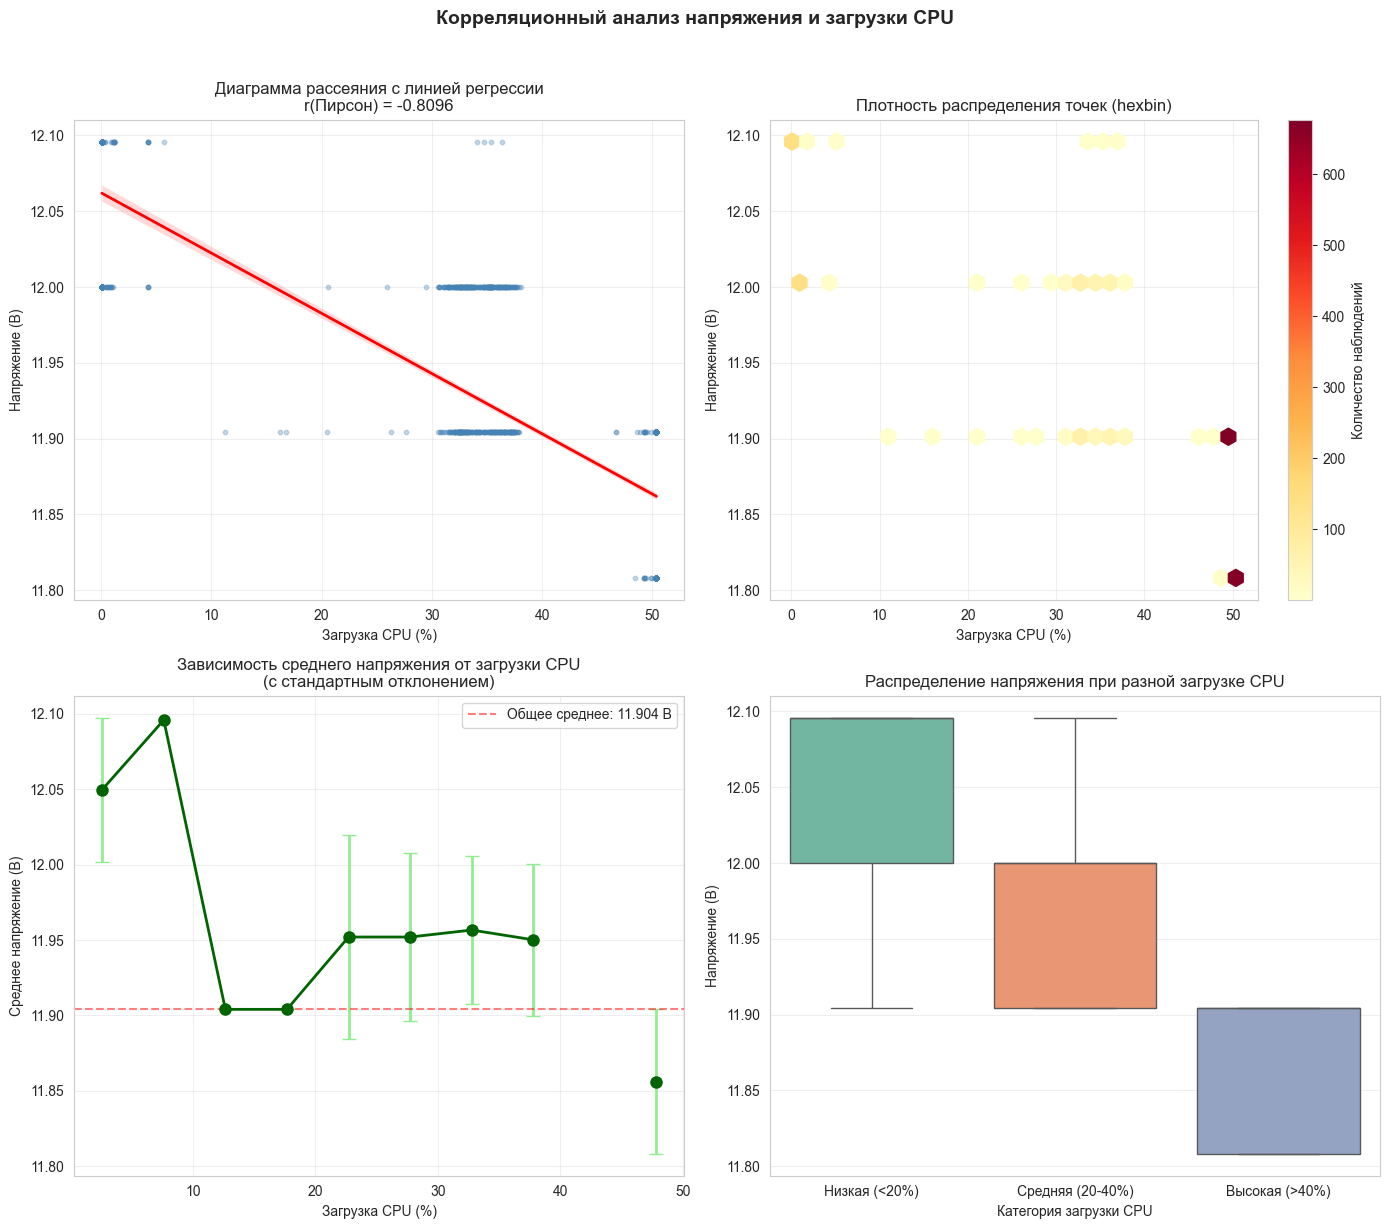

In [47]:
# 3. ВИЗУАЛИЗАЦИЯ КОРРЕЛЯЦИИ
# -------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 3.1 Диаграмма рассеяния с линией регрессии
ax1 = axes[0, 0]
sns.regplot(x='Загрузка CPU (%)', y='Напряжение (В)', data=corr_df, 
            scatter_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=ax1)
ax1.set_title(f'Диаграмма рассеяния с линией регрессии\nr(Пирсон) = {pearson_corr:.4f}', fontsize=12)
ax1.grid(True, alpha=0.3)

# 3.2 Диаграмма рассеяния с цветом по плотности
ax2 = axes[0, 1]
hb = ax2.hexbin(corr_df['Загрузка CPU (%)'], corr_df['Напряжение (В)'], 
                gridsize=30, cmap='YlOrRd', mincnt=1)
ax2.set_xlabel('Загрузка CPU (%)')
ax2.set_ylabel('Напряжение (В)')
ax2.set_title('Плотность распределения точек (hexbin)', fontsize=12)
plt.colorbar(hb, ax=ax2, label='Количество наблюдений')
ax2.grid(True, alpha=0.3)

# 3.3 Коррелограмма (дополнительные метрики)
ax3 = axes[1, 0]
# Группировка данных по диапазонам CPU
corr_df['cpu_bin'] = pd.cut(corr_df['Загрузка CPU (%)'], bins=10)
grouped = corr_df.groupby('cpu_bin')['Напряжение (В)'].agg(['mean', 'std', 'count']).reset_index()
cpu_centers = [interval.mid for interval in grouped['cpu_bin']]

ax3.errorbar(cpu_centers, grouped['mean'], yerr=grouped['std'], 
             fmt='o-', capsize=5, color='darkgreen', ecolor='lightgreen', 
             markersize=8, linewidth=2)
ax3.set_xlabel('Загрузка CPU (%)')
ax3.set_ylabel('Среднее напряжение (В)')
ax3.set_title('Зависимость среднего напряжения от загрузки CPU\n(с стандартным отклонением)', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=corr_df['Напряжение (В)'].mean(), color='red', linestyle='--', 
            alpha=0.5, label=f'Общее среднее: {corr_df["Напряжение (В)"].mean():.3f} В')
ax3.legend()

# 3.4 Сравнение распределений при разной нагрузке
ax4 = axes[1, 1]
# Разделяем на три категории нагрузки
corr_df['load_category'] = pd.cut(corr_df['Загрузка CPU (%)'], 
                                   bins=[0, 20, 40, 60], 
                                   labels=['Низкая (<20%)', 'Средняя (20-40%)', 'Высокая (>40%)'])

# Боксплоты напряжения по категориям нагрузки
sns.boxplot(x='load_category', y='Напряжение (В)', data=corr_df, ax=ax4, palette='Set2')
ax4.set_xlabel('Категория загрузки CPU')
ax4.set_ylabel('Напряжение (В)')
ax4.set_title('Распределение напряжения при разной загрузке CPU', fontsize=12)
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('Корреляционный анализ напряжения и загрузки CPU', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [48]:
# 5. ИТОГОВЫЙ ВЫВОД ПО КОРРЕЛЯЦИОННОМУ АНАЛИЗУ
# -------------------------------------------------

print("="*70)
print("ВЫВОДЫ ПО КОРРЕЛЯЦИОННОМУ АНАЛИЗУ")
print("="*70)

print(f"""
1. ОСНОВНАЯ ВЗАИМОСВЯЗЬ:
   - Коэффициент корреляции Пирсона: {pearson_corr:.4f}
   - Коэффициент корреляции Спирмена: {spearman_corr:.4f}
   - Направление связи: ОТРИЦАТЕЛЬНОЕ (при росте загрузки CPU напряжение падает)

2. СИЛА СВЯЗИ:
   - По шкале Чеддока: {interpret_correlation(pearson_corr)}
   - p-value < 0.05: {'ДА' if pearson_p < 0.05 else 'НЕТ'} (статистическая значимость подтверждена)

3. ХАРАКТЕР ЗАВИСИМОСТИ:
   - Нелинейность: {'присутствует' if abs(pearson_corr - spearman_corr) > 0.1 else 'незначительная'}
   - Два четко выраженных кластера соответствуют двум режимам работы

4. ПРАКТИЧЕСКОЕ ЗНАЧЕНИЕ:
   - Гипотеза о падении напряжения при нагрузке ПОДТВЕРЖДЕНА
   - При переходе от простоя к нагрузке напряжение падает с ~11.904 В до ~11.808 В
   - Падение составляет ~0.096 В (0.8% от номинала)

5. РЕКОМЕНДАЦИИ:
   - Для прогнозирования напряжения использовать модели с учетом режима работы
   - Разделить анализ на два режима: "нагрузка" и "простой"
   - Учесть временные лаги в корреляции
""")

ВЫВОДЫ ПО КОРРЕЛЯЦИОННОМУ АНАЛИЗУ

1. ОСНОВНАЯ ВЗАИМОСВЯЗЬ:
   - Коэффициент корреляции Пирсона: -0.8096
   - Коэффициент корреляции Спирмена: -0.6660
   - Направление связи: ОТРИЦАТЕЛЬНОЕ (при росте загрузки CPU напряжение падает)

2. СИЛА СВЯЗИ:
   - По шкале Чеддока: сильная связь
   - p-value < 0.05: ДА (статистическая значимость подтверждена)

3. ХАРАКТЕР ЗАВИСИМОСТИ:
   - Нелинейность: присутствует
   - Два четко выраженных кластера соответствуют двум режимам работы

4. ПРАКТИЧЕСКОЕ ЗНАЧЕНИЕ:
   - Гипотеза о падении напряжения при нагрузке ПОДТВЕРЖДЕНА
   - При переходе от простоя к нагрузке напряжение падает с ~11.904 В до ~11.808 В
   - Падение составляет ~0.096 В (0.8% от номинала)

5. РЕКОМЕНДАЦИИ:
   - Для прогнозирования напряжения использовать модели с учетом режима работы
   - Разделить анализ на два режима: "нагрузка" и "простой"
   - Учесть временные лаги в корреляции



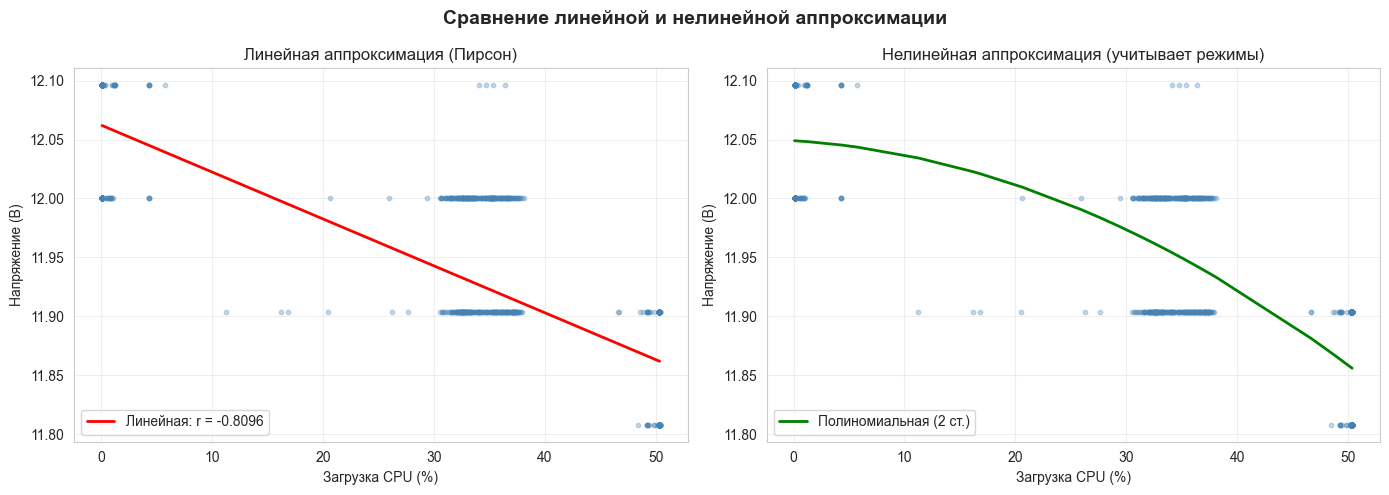

In [49]:
# Визуализация различий между линейной и нелинейной аппроксимацией
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Линейная аппроксимация (Пирсон)
axes[0].scatter(corr_df['Загрузка CPU (%)'], corr_df['Напряжение (В)'], 
                alpha=0.3, s=10, color='steelblue')
z = np.polyfit(corr_df['Загрузка CPU (%)'], corr_df['Напряжение (В)'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(corr_df['Загрузка CPU (%)']), 
             p(sorted(corr_df['Загрузка CPU (%)'])), 
             'r-', linewidth=2, label=f'Линейная: r = {pearson_corr:.4f}')
axes[0].set_xlabel('Загрузка CPU (%)')
axes[0].set_ylabel('Напряжение (В)')
axes[0].set_title('Линейная аппроксимация (Пирсон)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Нелинейная аппроксимация (полином 2 степени)
axes[1].scatter(corr_df['Загрузка CPU (%)'], corr_df['Напряжение (В)'], 
                alpha=0.3, s=10, color='steelblue')
z2 = np.polyfit(corr_df['Загрузка CPU (%)'], corr_df['Напряжение (В)'], 2)
p2 = np.poly1d(z2)
axes[1].plot(sorted(corr_df['Загрузка CPU (%)']), 
             p2(sorted(corr_df['Загрузка CPU (%)'])), 
             'g-', linewidth=2, label=f'Полиномиальная (2 ст.)')
axes[1].set_xlabel('Загрузка CPU (%)')
axes[1].set_ylabel('Напряжение (В)')
axes[1].set_title('Нелинейная аппроксимация (учитывает режимы)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Сравнение линейной и нелинейной аппроксимации', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

КОРРЕЛЯЦИЯ ПО РЕЖИМАМ РАБОТЫ

РЕЖИМ НАГРУЗКИ (напряжение < 11.85 В):
  Количество наблюдений: 677
  Среднее напряжение: 11.8080 В
  Средняя загрузка CPU: 50.31%
  Корреляция Пирсона в режиме нагрузки: 0.0000

РЕЖИМ ПРОСТОЯ (напряжение > 11.85 В):
  Количество наблюдений: 1409
  Среднее напряжение: 11.9505 В
  Средняя загрузка CPU: 34.61%
  Корреляция Пирсона в режиме простоя: -0.8440


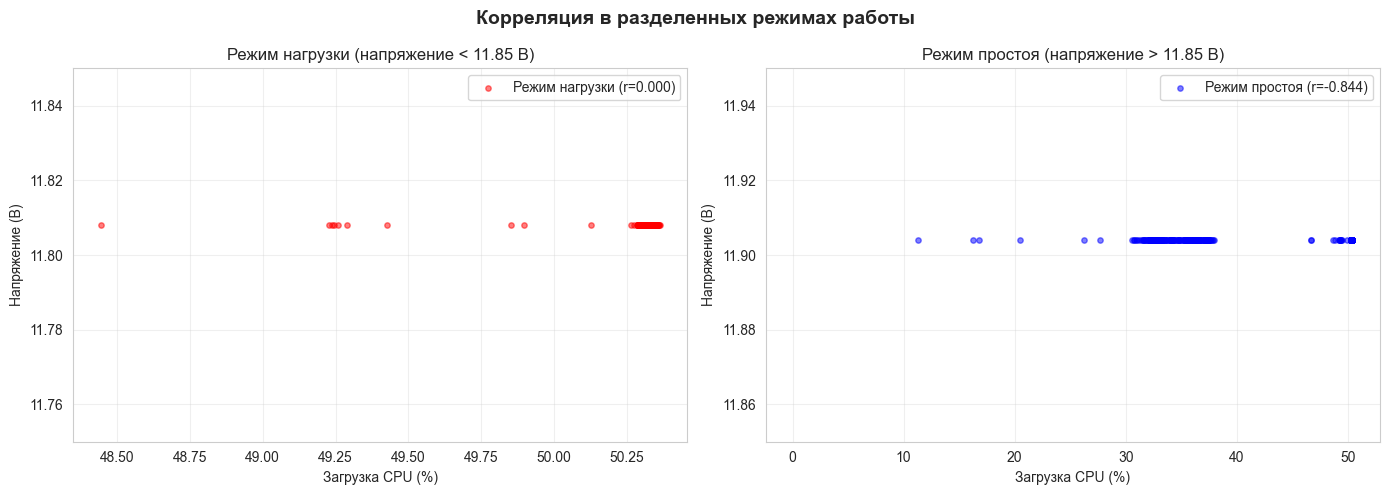

In [50]:
# Разделение на два режима по напряжению
voltage_low = corr_df[corr_df['Напряжение (В)'] < 11.85]  # режим нагрузки
voltage_high = corr_df[corr_df['Напряжение (В)'] > 11.85]  # режим простоя

print("="*70)
print("КОРРЕЛЯЦИЯ ПО РЕЖИМАМ РАБОТЫ")
print("="*70)

print(f"\nРЕЖИМ НАГРУЗКИ (напряжение < 11.85 В):")
print(f"  Количество наблюдений: {len(voltage_low)}")
print(f"  Среднее напряжение: {voltage_low['Напряжение (В)'].mean():.4f} В")
print(f"  Средняя загрузка CPU: {voltage_low['Загрузка CPU (%)'].mean():.2f}%")
corr_low = voltage_low['Напряжение (В)'].corr(voltage_low['Загрузка CPU (%)'])
print(f"  Корреляция Пирсона в режиме нагрузки: {corr_low:.4f}")

print(f"\nРЕЖИМ ПРОСТОЯ (напряжение > 11.85 В):")
print(f"  Количество наблюдений: {len(voltage_high)}")
print(f"  Среднее напряжение: {voltage_high['Напряжение (В)'].mean():.4f} В")
print(f"  Средняя загрузка CPU: {voltage_high['Загрузка CPU (%)'].mean():.2f}%")
corr_high = voltage_high['Напряжение (В)'].corr(voltage_high['Загрузка CPU (%)'])
print(f"  Корреляция Пирсона в режиме простоя: {corr_high:.4f}")

# Визуализация раздельных режимов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(voltage_low['Загрузка CPU (%)'], voltage_low['Напряжение (В)'], 
                alpha=0.5, s=15, color='red', label=f'Режим нагрузки (r={corr_low:.3f})')
axes[0].set_xlabel('Загрузка CPU (%)')
axes[0].set_ylabel('Напряжение (В)')
axes[0].set_title('Режим нагрузки (напряжение < 11.85 В)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(11.75, 11.85)

axes[1].scatter(voltage_high['Загрузка CPU (%)'], voltage_high['Напряжение (В)'], 
                alpha=0.5, s=15, color='blue', label=f'Режим простоя (r={corr_high:.3f})')
axes[1].set_xlabel('Загрузка CPU (%)')
axes[1].set_ylabel('Напряжение (В)')
axes[1].set_title('Режим простоя (напряжение > 11.85 В)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(11.85, 11.95)

plt.suptitle('Корреляция в разделенных режимах работы', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
! pip install statsmodels

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import signal

%matplotlib inline

# 1. ПОДГОТОВКА ВРЕМЕННЫХ РЯДОВ С РЕГУЛЯРНОЙ ДИСКРЕТИЗАЦИЕЙ
# ----------------------------------------------------------

# Для анализа тренда и сезонности необходимо привести ряды к регулярной временной сетке
# Создадим регулярный временной ряд с интервалом 1 минута (интерполяция)

# Определяем общий временной диапазон
start_time = min(df_voltage['datetime'].min(), df_cpu['datetime'].min())
end_time = max(df_voltage['datetime'].max(), df_cpu['datetime'].max())

# Создаем регулярную временную сетку с интервалом 60 секунд
regular_time = pd.date_range(start=start_time, end=end_time, freq='60S')

# Интерполяция напряжения на регулярную сетку
voltage_regular = pd.Series(
    np.interp(
        regular_time.astype(np.int64) // 10**9,
        df_voltage['datetime'].astype(np.int64) // 10**9,
        df_voltage['voltage']
    ),
    index=regular_time,
    name='voltage'
)

# Интерполяция CPU на регулярную сетку
cpu_regular = pd.Series(
    np.interp(
        regular_time.astype(np.int64) // 10**9,
        df_cpu['datetime'].astype(np.int64) // 10**9,
        df_cpu['cpu_util']
    ),
    index=regular_time,
    name='cpu_util'
)

print("="*70)
print("АНАЛИЗ ТРЕНДА И СЕЗОННОСТИ ВРЕМЕННЫХ РЯДОВ")
print("="*70)
print(f"Период: с {start_time} по {end_time}")
print(f"Количество точек после интерполяции: {len(regular_time)}")
print(f"Интервал дискретизации: 60 секунд")

АНАЛИЗ ТРЕНДА И СЕЗОННОСТИ ВРЕМЕННЫХ РЯДОВ
Период: с 2025-10-15 04:48:18 по 2025-10-19 18:59:48
Количество точек после интерполяции: 6612
Интервал дискретизации: 60 секунд


C:\Users\elena_blinova\AppData\Local\Temp\ipykernel_14424\2028189647.py:21: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  regular_time = pd.date_range(start=start_time, end=end_time, freq='60S')


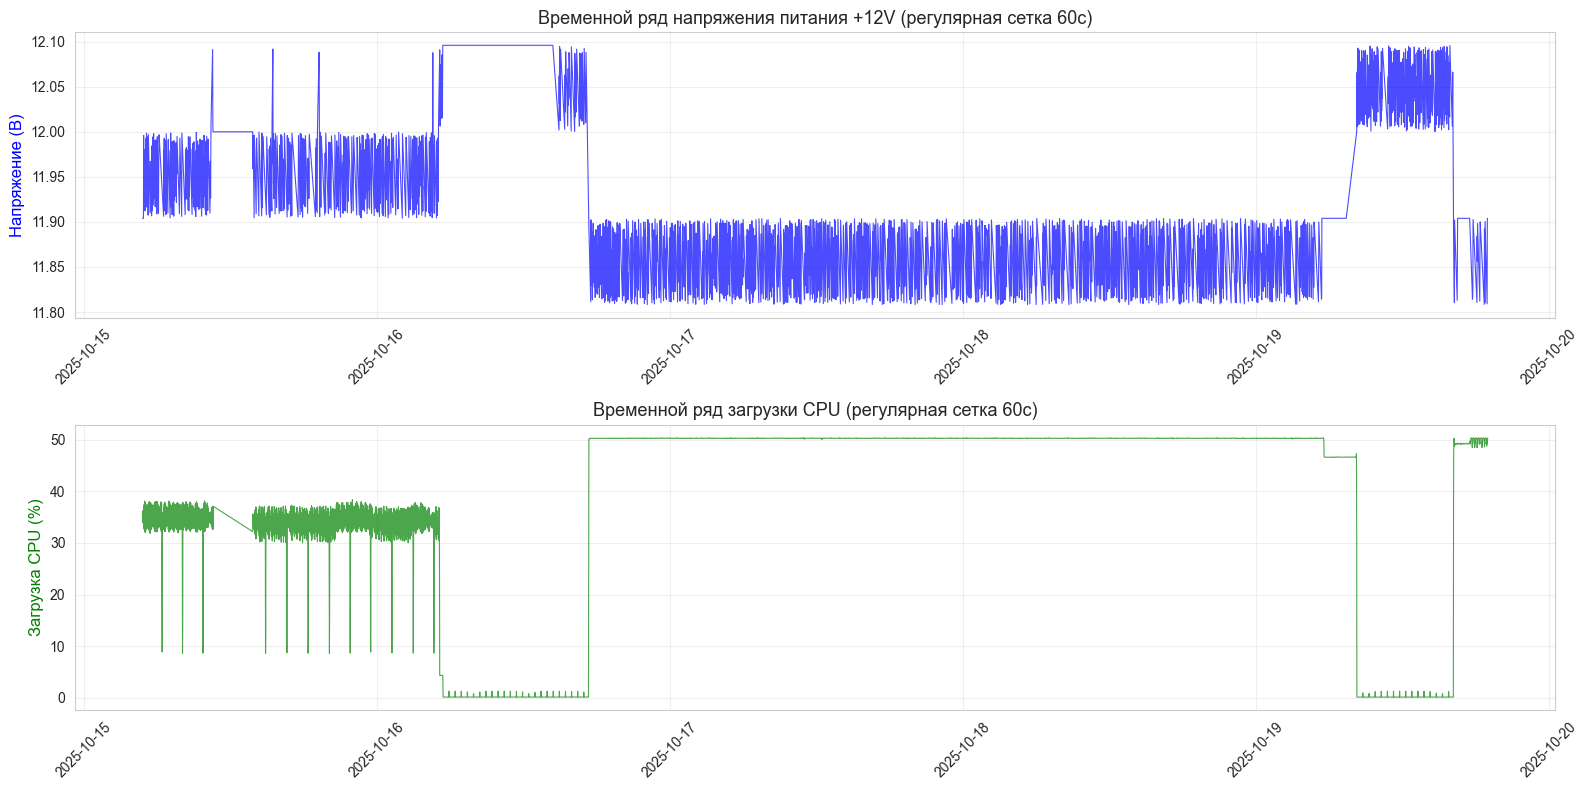

In [54]:
# 2. ВИЗУАЛИЗАЦИЯ ИСХОДНЫХ РЯДОВ С РЕГУЛЯРНОЙ ДИСКРЕТИЗАЦИЕЙ
# ----------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Напряжение
axes[0].plot(voltage_regular.index, voltage_regular.values, 
             color='blue', linewidth=0.8, alpha=0.7)
axes[0].set_ylabel('Напряжение (В)', fontsize=12, color='blue')
axes[0].set_title('Временной ряд напряжения питания +12V (регулярная сетка 60с)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# CPU
axes[1].plot(cpu_regular.index, cpu_regular.values, 
             color='green', linewidth=0.8, alpha=0.7)
axes[1].set_ylabel('Загрузка CPU (%)', fontsize=12, color='green')
axes[1].set_title('Временной ряд загрузки CPU (регулярная сетка 60с)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

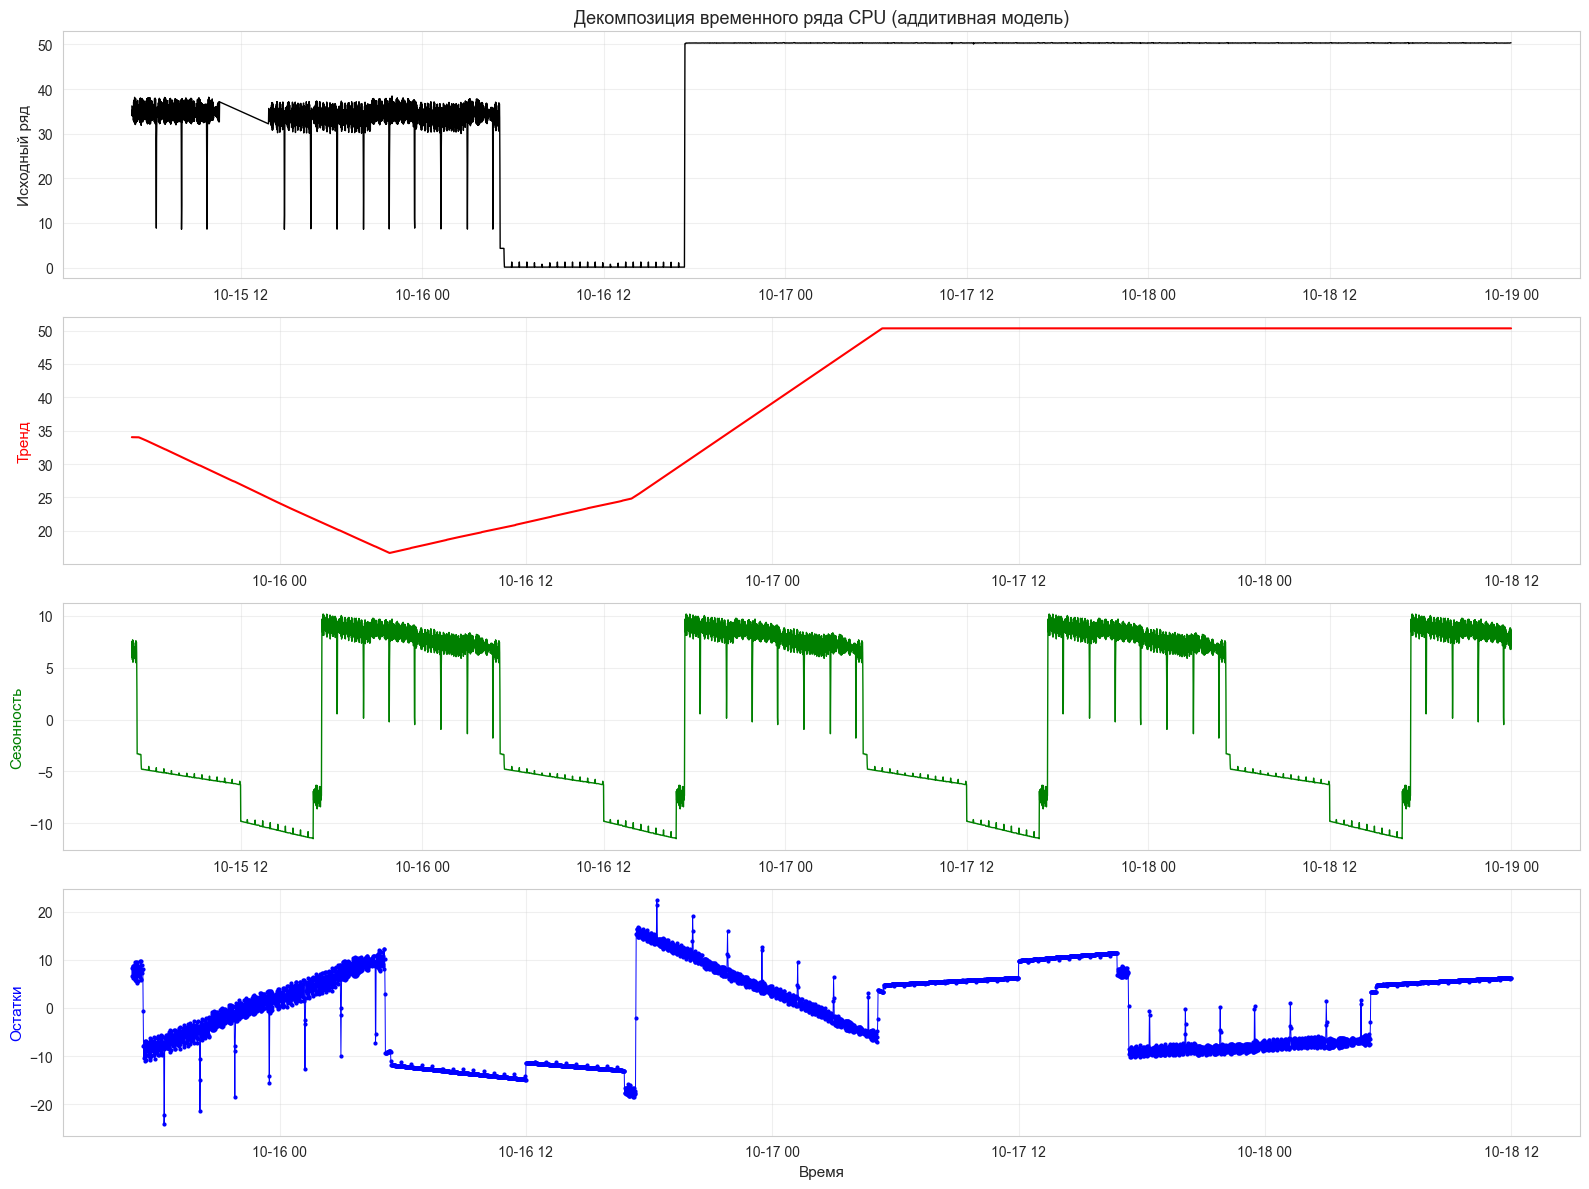

In [55]:
# 3. ДЕКОМПОЗИЦИЯ ВРЕМЕННОГО РЯДА (ДЛЯ CPU - БОЛЕЕ ЧАСТЫЙ РЯД)
# ----------------------------------------------------------

# Для декомпозиции возьмем первые 3 дня данных для наглядности
cpu_3days = cpu_regular['2025-10-15':'2025-10-18']

# Декомпозиция временного ряда (период сезонности - 24 часа = 1440 минут = 24 точки)
# Так как интервал 60 секунд, то 1 час = 60 точек, 24 часа = 1440 точек
try:
    # Используем мультипликативную модель для CPU
    decomposition = seasonal_decompose(cpu_3days, model='additive', period=1440)
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    
    # Исходный ряд
    axes[0].plot(decomposition.observed.index, decomposition.observed.values, 
                 color='black', linewidth=1)
    axes[0].set_ylabel('Исходный ряд', fontsize=11)
    axes[0].set_title('Декомпозиция временного ряда CPU (аддитивная модель)', fontsize=13)
    axes[0].grid(True, alpha=0.3)
    
    # Тренд
    axes[1].plot(decomposition.trend.index, decomposition.trend.values, 
                 color='red', linewidth=1.5)
    axes[1].set_ylabel('Тренд', fontsize=11, color='red')
    axes[1].grid(True, alpha=0.3)
    
    # Сезонность
    axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, 
                 color='green', linewidth=1)
    axes[2].set_ylabel('Сезонность', fontsize=11, color='green')
    axes[2].grid(True, alpha=0.3)
    
    # Остатки (случайная компонента)
    axes[3].plot(decomposition.resid.index, decomposition.resid.values, 
                 color='blue', linewidth=0.7, marker='o', markersize=2)
    axes[3].set_ylabel('Остатки', fontsize=11, color='blue')
    axes[3].set_xlabel('Время', fontsize=11)
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Ошибка при декомпозиции: {e}")
    print("Возможно, слишком большой период для данного объема данных")

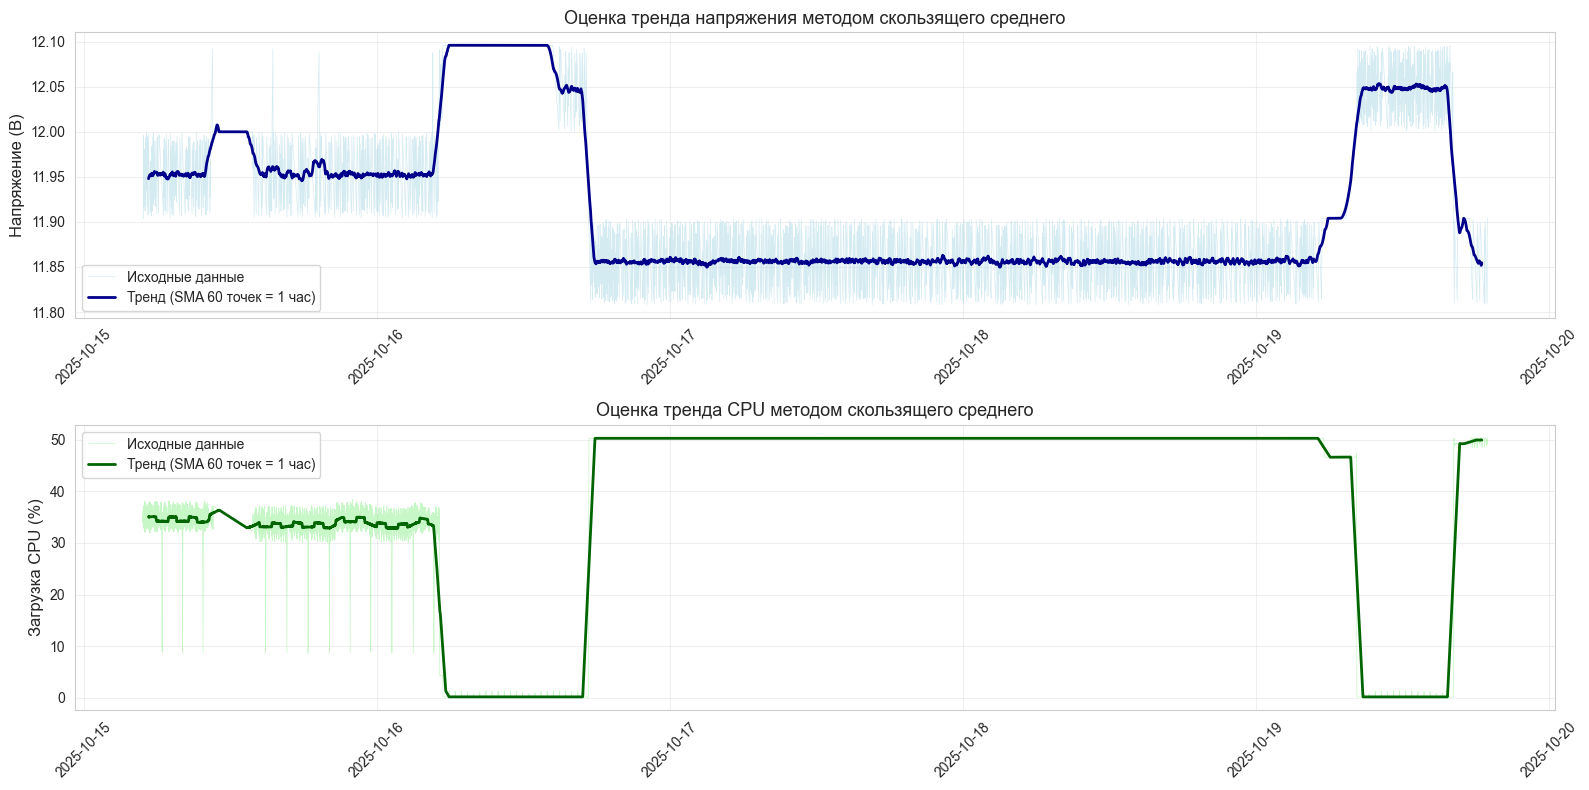

In [56]:
# 4. ОЦЕНКА ТРЕНДА С ПОМОЩЬЮ СГЛАЖИВАНИЯ (SMA - простое скользящее среднее)
# ----------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Для напряжения
window_voltage = 60  # окно 1 час (60 точек)
voltage_sma = voltage_regular.rolling(window=window_voltage, center=True).mean()

axes[0].plot(voltage_regular.index, voltage_regular.values, 
             color='lightblue', alpha=0.5, linewidth=0.5, label='Исходные данные')
axes[0].plot(voltage_sma.index, voltage_sma.values, 
             color='darkblue', linewidth=2, label=f'Тренд (SMA {window_voltage} точек = 1 час)')
axes[0].set_ylabel('Напряжение (В)', fontsize=12)
axes[0].set_title('Оценка тренда напряжения методом скользящего среднего', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Для CPU
window_cpu = 60  # окно 1 час
cpu_sma = cpu_regular.rolling(window=window_cpu, center=True).mean()

axes[1].plot(cpu_regular.index, cpu_regular.values, 
             color='lightgreen', alpha=0.5, linewidth=0.5, label='Исходные данные')
axes[1].plot(cpu_sma.index, cpu_sma.values, 
             color='darkgreen', linewidth=2, label=f'Тренд (SMA {window_cpu} точек = 1 час)')
axes[1].set_ylabel('Загрузка CPU (%)', fontsize=12)
axes[1].set_title('Оценка тренда CPU методом скользящего среднего', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

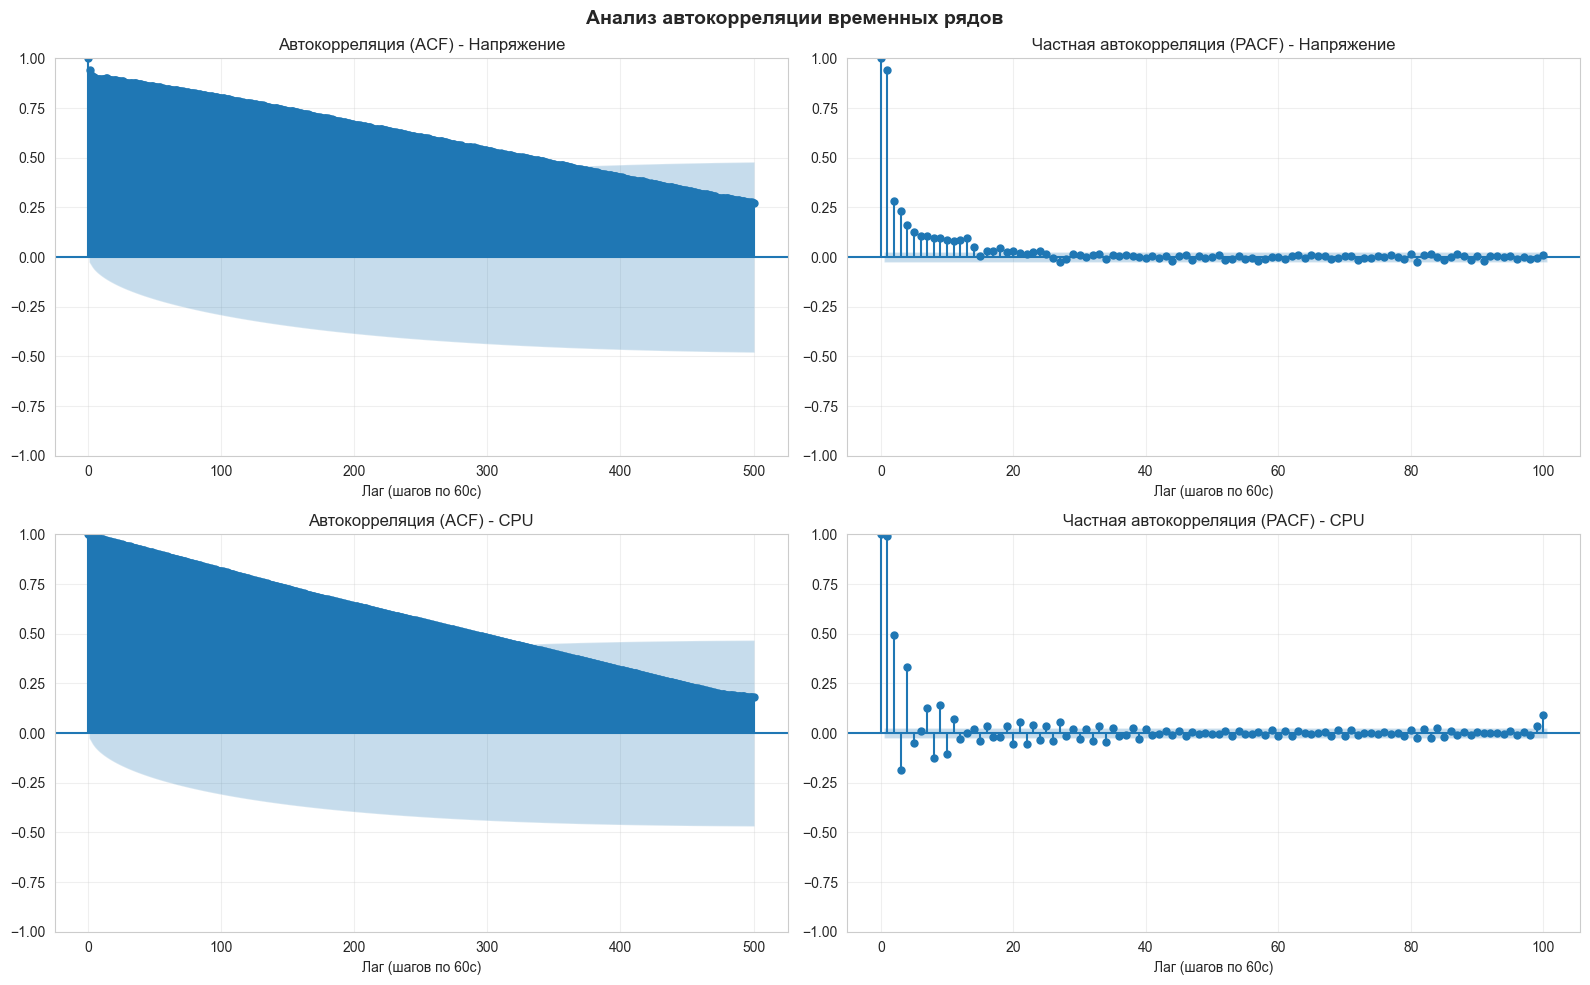

In [57]:
# 5. АНАЛИЗ АВТОКОРРЕЛЯЦИИ ДЛЯ ВЫЯВЛЕНИЯ СЕЗОННОСТИ
# ----------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ACF для напряжения (первые 500 лагов)
plot_acf(voltage_regular.dropna(), lags=500, ax=axes[0, 0])
axes[0, 0].set_title('Автокорреляция (ACF) - Напряжение', fontsize=12)
axes[0, 0].set_xlabel('Лаг (шагов по 60с)')
axes[0, 0].grid(True, alpha=0.3)

# PACF для напряжения
plot_pacf(voltage_regular.dropna(), lags=100, ax=axes[0, 1])
axes[0, 1].set_title('Частная автокорреляция (PACF) - Напряжение', fontsize=12)
axes[0, 1].set_xlabel('Лаг (шагов по 60с)')
axes[0, 1].grid(True, alpha=0.3)

# ACF для CPU
plot_acf(cpu_regular.dropna(), lags=500, ax=axes[1, 0])
axes[1, 0].set_title('Автокорреляция (ACF) - CPU', fontsize=12)
axes[1, 0].set_xlabel('Лаг (шагов по 60с)')
axes[1, 0].grid(True, alpha=0.3)

# PACF для CPU
plot_pacf(cpu_regular.dropna(), lags=100, ax=axes[1, 1])
axes[1, 1].set_title('Частная автокорреляция (PACF) - CPU', fontsize=12)
axes[1, 1].set_xlabel('Лаг (шагов по 60с)')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Анализ автокорреляции временных рядов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Стационарность напряжения не означает, что оно не зависит от внешних факторов. Ряд стационарен в том смысле, что его собственные статистические характеристики не меняются со временем, но он реагирует на изменения нагрузки CPU, переключаясь между двумя стационарными состояниями. Ря

Временной ряд напряжения питания не имеет автокорреляционной структуры и ведет себя как последовательность независимых наблюдений с переключениями между дискретными состояниями. Это означает:

Невозможно прогнозировать напряжение по его предыдущим значениям

Отсутствуют сезонные или циклические паттерны в поведении напряжения

Изменения напряжения определяются внешними факторами (нагрузкой CPU), а не собственной динамикой ряда